# 💳 BNPL Risk & Profitability Optimization Analysis

## 1. Problem Statement
> **How can a BNPL company reduce missed payments while maximizing customer lifetime value (CLV) and long-term profitability?**

## 2. Objectives
To address the problem statement, this project is structured around the following key technical and business goals:

* **Identify High-Risk Customers** 
* **Analyze Default Behavior** 
* **Calculate Profitability** 
* **Segment Customers by Risk & CLV**
* **Recommend Credit Optimization Strategy** 


Data Loading

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv("bnpl_full_sample.csv")
df.head()

,transaction_id,purchase_date,customer_id,merchant_category,merchant_name,customer_state,principal_ngn,interest_rate_monthly,tenor_days,num_installments,provider,credit_score,first_time_customer,first_payment_due,default_30d,default_90d
0,BNPL-0000274330,10-07-24,CUS-00036437,groceries,Groceries Store 105,Oyo,35416.98913,0.000000,14,1,FairMoney,645,False,09-08-24,False,False
1,BNPL-0001873807,01-08-23,CUS-00131005,furniture,Furniture Store 820,Lagos,43154.84671,0.000000,30,1,FairMoney,716,True,31-08-23,False,False
2,BNPL-0001029126,12-02-22,CUS-00648656,electronics,Electronics Store 346,Abuja (FCT),247235.61510,0.000000,14,1,Branch,470,False,14-03-22,False,False
3,BNPL-0001512791,26-01-23,CUS-00611557,furniture,Furniture Store 393,Lagos,70679.21723,0.032728,30,1,Branch,620,False,25-02-23,False,False
4,BNPL-0000552055,12-01-23,CUS-00499951,fashion,Fashion Store 956,Ekiti,225083.50430,0.049655,90,3,Branch,536,False,11-02-23,False,False


In [2]:
df.shape

(100, 16)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   transaction_id         100 non-null    object 
 1   purchase_date          100 non-null    object 
 2   customer_id            100 non-null    object 
 3   merchant_category      100 non-null    object 
 4   merchant_name          100 non-null    object 
 5   customer_state         100 non-null    object 
 6   principal_ngn          100 non-null    float64
 7   interest_rate_monthly  100 non-null    float64
 8   tenor_days             100 non-null    int64  
 9   num_installments       100 non-null    int64  
 10  provider               100 non-null    object 
 11  credit_score           100 non-null    int64  
 12  first_time_customer    100 non-null    bool   
 13  first_payment_due      100 non-null    object 
 14  default_30d            100 non-null    bool   
 15  default

In [4]:
df.describe()

,principal_ngn,interest_rate_monthly,tenor_days,num_installments,credit_score
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,49698.268910,0.022998,37.340000,1.330000,617.730000
std,62844.019520,0.018626,21.651146,0.652191,79.205251
min,5000.000000,0.000000,14.000000,1.000000,440.000000
25%,20385.277275,0.000000,30.000000,1.000000,559.500000
50%,32420.891765,0.027986,30.000000,1.000000,627.500000
75%,55549.044695,0.039234,30.000000,1.000000,675.000000
max,500000.000000,0.049655,90.000000,3.000000,807.000000


Data Cleaning

In [5]:
df.isnull().sum()

transaction_id           0
purchase_date            0
customer_id              0
merchant_category        0
merchant_name            0
customer_state           0
principal_ngn            0
interest_rate_monthly    0
tenor_days               0
num_installments         0
provider                 0
credit_score             0
first_time_customer      0
first_payment_due        0
default_30d              0
default_90d              0
dtype: int64

In [6]:
df.fillna(0, inplace=True)

In [7]:
df['purchase_date'] = pd.to_datetime(df['purchase_date'], format='%d-%m-%y')
df['first_payment_due'] = pd.to_datetime(df['first_payment_due'], format='%d-%m-%y')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   transaction_id         100 non-null    object        
 1   purchase_date          100 non-null    datetime64[ns]
 2   customer_id            100 non-null    object        
 3   merchant_category      100 non-null    object        
 4   merchant_name          100 non-null    object        
 5   customer_state         100 non-null    object        
 6   principal_ngn          100 non-null    float64       
 7   interest_rate_monthly  100 non-null    float64       
 8   tenor_days             100 non-null    int64         
 9   num_installments       100 non-null    int64         
 10  provider               100 non-null    object        
 11  credit_score           100 non-null    int64         
 12  first_time_customer    100 non-null    bool          
 13  first_

In [9]:
# Convert everything to string first
df['default_30d'] = df['default_30d'].astype(str).str.strip().str.lower()
df['default_90d'] = df['default_90d'].astype(str).str.strip().str.lower()

# Convert to 0 and 1
df['default_30d'] = np.where(df['default_30d'] == 'true', 1, 0)
df['default_90d'] = np.where(df['default_90d'] == 'true', 1, 0) 

Feature Engineering

In [10]:
df['calculated_interest'] = df['principal_ngn'] * df['interest_rate_monthly'] * (df['tenor_days']/30)

In [11]:
total_interest = df['calculated_interest'].sum()
total_interest 

np.float64(178408.5587460935)

In [12]:
df['loss_amount'] = np.where(df['default_90d'] == 1, df['principal_ngn'], 0)

In [13]:
total_loss = df['loss_amount'].sum()
total_loss

np.float64(212275.32632599998)

In [14]:
df['net_profit'] = df['calculated_interest'] - df['loss_amount']

In [15]:
def credit_bucket(score):
    if score < 550:
        return "High Risk"
    elif score < 650:
        return "Medium Risk"
    else:
        return "Low Risk"

df['risk_segment'] = df['credit_score'].apply(credit_bucket)

In [16]:
df.head()

,transaction_id,purchase_date,customer_id,merchant_category,merchant_name,customer_state,principal_ngn,interest_rate_monthly,tenor_days,num_installments,provider,credit_score,first_time_customer,first_payment_due,default_30d,default_90d,calculated_interest,loss_amount,net_profit,risk_segment
0,BNPL-0000274330,2024-07-10,CUS-00036437,groceries,Groceries Store 105,Oyo,35416.98913,0.000000,14,1,FairMoney,645,False,2024-08-09,0,0,0.000000,0.0,0.000000,Medium Risk
1,BNPL-0001873807,2023-08-01,CUS-00131005,furniture,Furniture Store 820,Lagos,43154.84671,0.000000,30,1,FairMoney,716,True,2023-08-31,0,0,0.000000,0.0,0.000000,Low Risk
2,BNPL-0001029126,2022-02-12,CUS-00648656,electronics,Electronics Store 346,Abuja (FCT),247235.61510,0.000000,14,1,Branch,470,False,2022-03-14,0,0,0.000000,0.0,0.000000,High Risk
3,BNPL-0001512791,2023-01-26,CUS-00611557,furniture,Furniture Store 393,Lagos,70679.21723,0.032728,30,1,Branch,620,False,2023-02-25,0,0,2313.171540,0.0,2313.171540,Medium Risk
4,BNPL-0000552055,2023-01-12,CUS-00499951,fashion,Fashion Store 956,Ekiti,225083.50430,0.049655,90,3,Branch,536,False,2023-02-11,0,0,33529.720201,0.0,33529.720201,High Risk


Risk Analysis (Missed Payment Focus)

**Overall Default Rate**

In [17]:
default_rate = df['default_90d'].astype(float).mean() * 100
print(f"90D Default Rate: {default_rate:.2f}%") 

90D Default Rate: 7.00%


**Default by Risk Segment**

In [18]:
risk_default_rate = df.groupby('risk_segment')['default_90d'].mean() * 100
print("Default Rate By Risk Segment:\n", risk_default_rate.round(2).astype(str) + "%") 

Default Rate By Risk Segment:
 risk_segment
High Risk      14.29%
Low Risk         0.0%
Medium Risk     9.09%
Name: default_90d, dtype: object


**Default by Installments**

In [19]:
installment_default = df.groupby('num_installments')['default_90d'].mean() * 100
print(installment_default.round(2).astype(str) + "%") 

num_installments
1    9.09%
2     0.0%
3     0.0%
Name: default_90d, dtype: object


**Visualization**

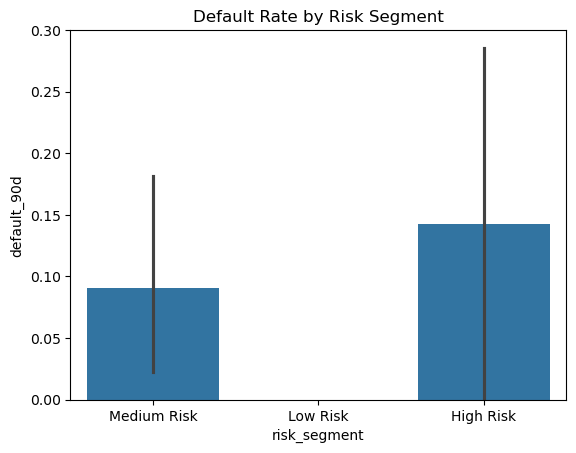

In [20]:
sns.barplot(data=df, x='risk_segment', y='default_90d')
plt.title("Default Rate by Risk Segment")
plt.show()

Profitability Analysis

**Total Net Profit**

In [21]:
df['net_profit'].sum()

np.float64(-33866.76757990653)

**Profit by Risk Segment**

In [22]:
df.groupby('risk_segment')['net_profit'].sum()

risk_segment
High Risk     -16520.201819
Low Risk       58452.388475
Medium Risk   -75798.954236
Name: net_profit, dtype: float64

**Profit by Provider**

In [23]:
df.groupby('provider')['net_profit'].sum()

provider
Branch       46181.774989
Carbon      -71869.794005
FairMoney   -10752.828194
PayLater     16627.604881
Renmoney    -14053.525251
Name: net_profit, dtype: float64

Customer Lifetime Value (CLV)

In [24]:
clv = df.groupby('customer_id')['net_profit'].sum().reset_index()
clv.columns = ['customer_id','CLV']
clv.head()

,customer_id,CLV
0,CUS-00015326,2463.890259
1,CUS-00017739,1060.534912
2,CUS-00031195,0.000000
3,CUS-00034586,0.000000
4,CUS-00035101,1384.626472


In [25]:
df = df.merge(clv, on='customer_id', how='left')

In [26]:
df.groupby('risk_segment')['CLV'].mean()

risk_segment
High Risk      -786.676277
Low Risk       1670.068242
Medium Risk   -1722.703505
Name: CLV, dtype: float64

Advanced Insight

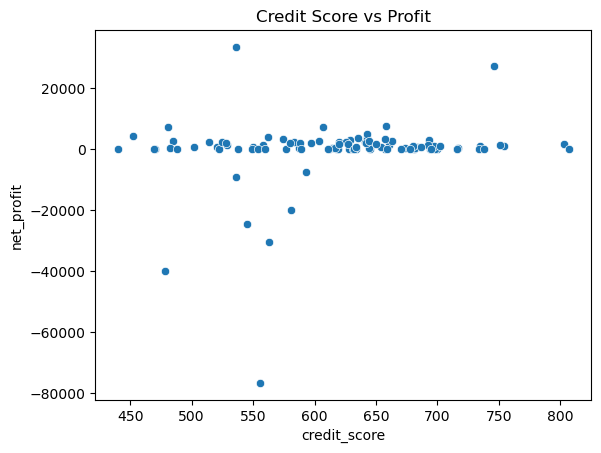

In [27]:
sns.scatterplot(data=df, x='credit_score', y='net_profit')
plt.title("Credit Score vs Profit")
plt.show()

# Final Insights

## 📦 Dataset
- 100 transactions | 16 features | Nigerian Market (NGN)
- No missing values | Clean & ready for analysis

## ⚠️ Default Rate
- Overall 90-Day Default → **7.00%**
- High Risk (score < 550) → **14.29%** 🔴
- Medium Risk (550–650) → **9.09%** 🟡
- Low Risk (score > 650) → **0.00%** 🟢
- Single installment default (9.09%) vs Multi-installment (0%) ✅

## 💰 Profitability
- Interest Earned → ₦178,409
- Default Losses → ₦212,275
- Net Profit → **–₦33,867** ❌ (Portfolio is LOSS-MAKING)
- By Segment → Low Risk: +₦58,452 ✅ | Medium: –₦75,799 ❌
- By Provider → Branch: +₦46,182 ✅ | Carbon: –₦71,870 ❌

## 👤 Customer Lifetime Value (CLV)
- Low Risk → **+₦1,670** 🟢 (Best)
- High Risk → **–₦787** 🔴
- Medium Risk → **–₦1,723** 🔴 (Worst — even worse than High Risk!)

## ✅ Conclusion
- Portfolio is currently **LOSS-MAKING** 📉
- Fix = Risk-adjusted pricing + Low Risk focus + Structured repayments